# Criticality Analysis of Overlapping Gene Systems

## Motivation

The overlapping genes system uses a DCA (Potts model) Hamiltonian with Monte Carlo sampling — the same mathematical framework as spin models that exhibit **phase transitions**. The overlap constraint introduces **frustration** between two proteins sharing nucleotides, analogous to geometric frustration in magnetic systems.

This notebook investigates whether this frustration produces observable **phase transition signatures** as a function of the MC temperatures $T_1$ and $T_2$:

- **Specific heat peaks** $C_v = \text{Var}(E) / T^2$ — diverge at continuous transitions
- **Susceptibility divergence** $\chi = \text{Var}(m) / T$ — measures order parameter fluctuations
- **Binder cumulant crossings** $U = 1 - \langle m^4 \rangle / (3\langle m^2 \rangle^2)$ — size-independent $T_c$ identification
- **Bimodality** in energy distributions — signature of first-order transitions

We use **2D Replica Exchange** with staggered grids for efficient sampling across the $(T_1, T_2)$ plane, with z-score normalization to make both temperature axes comparable.

In [36]:
import numpy as np

# ─── Protein pairs ───
# Selected for size diversity: reference + symmetric + 2 asymmetric
# (computed programmatically in Cell 3 based on actual protein lengths)
REFERENCE_PAIR = ("PF00004", "PF00041")

# ─── Coarse scan parameters ───
T_MIN, T_MAX = 0.1, 1.0
N_T = 8
N_STAGGER = 2  # 2² = 4 runs, 16×16 fine grid, 64 replicas/run

# ─── Refined scan parameters ───
N_T_REFINED = 8
N_STAGGER_REFINED = 3  # 3² = 9 runs, 24×24 fine grid, 64 replicas/run

# ─── MC parameters ───
BURNIN = 200_000
SAMPLES_COARSE = 5_000
SAMPLES_REFINED = 20_000
SAMPLE_INTERVAL = 100
SWAP_INTERVAL = 50

# ─── Default overlap (frame 0) ───
DEFAULT_OVERLAP = 60  # nucleotides, divisible by 3

# ─── Paths ───
DATA_DIR = "../Large Scale/bmDCA"
RE_DIR = "../Replica Exchange"
OPTIMAL_TEMPS_PATH = "../Project/optimal_temperatures.json"
CHECKPOINT_DIR = "checkpoints"

# ─── Derived ───
N_T_FINE = N_T * N_STAGGER
N_T_FINE_REFINED = N_T_REFINED * N_STAGGER_REFINED
N_RUNS_COARSE = N_STAGGER ** 2
N_RUNS_REFINED = N_STAGGER_REFINED ** 2
SEED_BASE = 42

# ─── Temperature grid spacing ───
# Geometric (log-uniform) spacing keeps Δ(1/T)/(1/T) constant across the
# grid, giving roughly uniform swap acceptance rates.  Linear spacing
# would compress β at low T, killing swaps there.
# Sub-grid adjacent ratio = (T_MAX/T_MIN)^(N_STAGGER / (N_T_FINE - 1))
r_sub = (T_MAX / T_MIN) ** (N_STAGGER / (N_T_FINE - 1))
print(f"Coarse: {N_T_FINE}×{N_T_FINE} fine grid, {N_RUNS_COARSE} runs of "
      f"{N_T}×{N_T}={N_T**2} replicas")
print(f"Refined: {N_T_FINE_REFINED}×{N_T_FINE_REFINED} fine grid, {N_RUNS_REFINED} runs of "
      f"{N_T_REFINED}×{N_T_REFINED}={N_T_REFINED**2} replicas")
print(f"Sub-grid adjacent T ratio: {r_sub:.3f}  (target ≈ 1.2–1.4 for ~40% swaps)")

Coarse: 16×16 fine grid, 4 runs of 8×8=64 replicas
Refined: 24×24 fine grid, 9 runs of 8×8=64 replicas
Sub-grid adjacent T ratio: 1.359  (target ≈ 1.2–1.4 for ~40% swaps)


In [37]:
import sys, os, json, time

sys.path.insert(0, RE_DIR)
from overlappingGenes import (
    extract_params, load_natural_energies, initial_seq_no_stops,
    seq_str_to_int_array, run_2d_replica_exchange
)
import pandas as pd

# ─── Load all protein families ───
families = sorted([d for d in os.listdir(DATA_DIR)
                   if os.path.isdir(os.path.join(DATA_DIR, d)) and d.startswith("PF")])

family_data = {}
for pf in families:
    params_file = f"{DATA_DIR}/{pf}/{pf}_params.dat"
    nat_file = f"{DATA_DIR}/{pf}/{pf}_naturalenergies.txt"
    Js, hs = extract_params(params_file)
    nat_e = np.array(load_natural_energies(nat_file))
    aa_len = int(len(hs) / 21)
    family_data[pf] = {
        'Js': Js, 'hs': hs,
        'nat_energies': nat_e,
        'mean': np.mean(nat_e), 'std': np.std(nat_e),
        'aa_len': aa_len, 'nt_len': 3 * aa_len + 3,
    }

# ─── Summary table ───
summary = pd.DataFrame({
    pf: {'AA length': d['aa_len'], 'NT length': d['nt_len'],
         'E_mean': f"{d['mean']:.1f}", 'E_std': f"{d['std']:.1f}"}
    for pf, d in family_data.items()
}).T
print(summary.to_string())

# ─── Load optimal temperatures ───
with open(OPTIMAL_TEMPS_PATH) as f:
    optimal_temps = json.load(f)
print(f"\nOptimal temperatures loaded for {len(optimal_temps)} families")

# ─── Select 4 pairs for analysis ───
lengths = {pf: d['aa_len'] for pf, d in family_data.items()}
sorted_fams = sorted(families, key=lambda pf: lengths[pf])

# Reference pair
pair_ref = REFERENCE_PAIR

# Symmetric: most similar lengths (excluding reference pair members)
available = [pf for pf in families if pf not in pair_ref]
best_sym, best_diff = None, float('inf')
for i, pf_a in enumerate(available):
    for pf_b in available[i+1:]:
        diff = abs(lengths[pf_a] - lengths[pf_b])
        if diff < best_diff:
            best_diff = diff
            best_sym = (pf_a, pf_b)
pair_sym = best_sym

# Asymmetric: shortest × longest, 2nd shortest × 2nd longest
pair_asym1 = (sorted_fams[0], sorted_fams[-1])
pair_asym2 = (sorted_fams[1], sorted_fams[-2])

PAIRS = [pair_ref, pair_sym, pair_asym1, pair_asym2]

print("\nSelected pairs:")
for label, (pf1, pf2) in zip(["Reference", "Symmetric", "Asymmetric 1", "Asymmetric 2"], PAIRS):
    print(f"  {label}: {pf1} ({lengths[pf1]} aa) × {pf2} ({lengths[pf2]} aa)")

# ─── JIT warmup (overlap must be >= 18 for valid sequence generation) ───
print("\nJIT warmup...", end=" ", flush=True)
pf1, pf2 = pair_ref
d1, d2 = family_data[pf1], family_data[pf2]
_ = run_2d_replica_exchange(
    [d1['Js'], d1['hs']], [d2['Js'], d2['hs']],
    d1['aa_len'], d2['aa_len'], 18,
    T1_grid=np.array([0.5, 1.0]),
    T2_grid=np.array([0.5, 1.0]),
    n_burnin=50, n_samples=5, sample_interval=10,
    swap_interval=10, nat_std1=d1['std'], nat_std2=d2['std'],
)
print("done")

        AA length NT length E_mean E_std
PF00004       110       333  145.9  38.2
PF00041        74       225  120.7  17.6
PF00072       108       327  201.4  30.0
PF00076        59       180   80.8  17.5
PF00096        23        72   16.4   5.2
PF00153        85       258   92.6  25.6
PF00271        95       288  149.6  27.2
PF00397        28        87   34.5   7.3
PF00512        62       189  105.7  17.7
PF00595        71       216   87.5  17.9
PF02518       101       306  186.8  26.1
PF07679        76       231   63.7  19.1

Optimal temperatures loaded for 12 families

Selected pairs:
  Reference: PF00004 (110 aa) × PF00041 (74 aa)
  Symmetric: PF00076 (59 aa) × PF00512 (62 aa)
  Asymmetric 1: PF00096 (23 aa) × PF00004 (110 aa)
  Asymmetric 2: PF00397 (28 aa) × PF00072 (108 aa)

JIT warmup... 2D RE: 2x2 = 4 replicas
  T1 range: [0.500, 1.000]
  T2 range: [0.500, 1.000]
  Burn-in: 50, Samples: 5, Sample interval: 10, Swap interval: 10


2D RE: 100%|██████████| 100/100 [00:00<00:00, 97541.95step/s]

2D RE completed in 0.00s (5 samples collected)
  Mean swap rate H: 0.667, V: 0.500
done


In [38]:
from scipy.signal import find_peaks
from scipy.stats import skew, kurtosis


def compute_order_parameters(Z1, Z2):
    """Compute multiple candidate order parameters from z-score samples.

    Returns: (asymmetry, combined, euclidean) arrays
    """
    abs_sum = np.abs(Z1) + np.abs(Z2)
    safe_sum = np.where(abs_sum > 0, abs_sum, 1.0)
    asymmetry = (Z1 - Z2) / safe_sum
    combined = abs_sum
    euclidean = np.sqrt(Z1**2 + Z2**2)
    return asymmetry, combined, euclidean


def specific_heat(E_samples, T):
    """Cv = Var(E) / T**2"""
    return np.var(E_samples) / T**2


def susceptibility(m_samples, T):
    """chi = Var(m) / T"""
    return np.var(m_samples) / T


def binder_cumulant(m_samples):
    """U = 1 - <m^4> / (3 <m^2>^2)"""
    m2 = np.mean(m_samples**2)
    m4 = np.mean(m_samples**4)
    if m2 == 0:
        return 0.0
    return 1.0 - m4 / (3.0 * m2**2)


def bimodality_coefficient(samples):
    """BC = (skew^2 + 1) / kurtosis_pearson. BC > 5/9 suggests bimodality."""
    s = skew(samples)
    k = kurtosis(samples, fisher=False)  # Pearson's kurtosis
    if k == 0:
        return 0.0
    return (s**2 + 1) / k


def find_cv_peaks_1d(Cv_array, T_array):
    """Locate peaks in a 1D specific heat curve."""
    prom = 0.1 * (np.max(Cv_array) - np.min(Cv_array))
    peak_idx, props = find_peaks(Cv_array, prominence=max(prom, 1e-6))
    return peak_idx, T_array[peak_idx], Cv_array[peak_idx]


def block_bootstrap_error(samples, fn, n_blocks=20):
    """Block bootstrap error estimate for a scalar statistic."""
    n = len(samples)
    block_size = max(1, n // n_blocks)
    stats = [fn(samples[i*block_size:(i+1)*block_size])
             for i in range(n_blocks) if (i+1)*block_size <= n]
    return np.std(stats) if len(stats) > 1 else 0.0


def compute_all_observables(E1_grid, E2_grid, T1_fine, T2_fine,
                            mean_1, std_1, mean_2, std_2):
    """Compute thermodynamic observables over the full (T2, T1) grid.

    E1_grid, E2_grid: shape (n_T2, n_T1, n_samples)
    Returns dict of 2D arrays over the grid.
    """
    nT2, nT1, ns = E1_grid.shape

    # Z-score transform
    Z1_grid = (E1_grid - mean_1) / std_1
    Z2_grid = (E2_grid - mean_2) / std_2

    # Pre-allocate
    Cv1 = np.zeros((nT2, nT1))
    Cv2 = np.zeros((nT2, nT1))
    Cv_total = np.zeros((nT2, nT1))
    chi_asym = np.zeros((nT2, nT1))
    chi_comb = np.zeros((nT2, nT1))
    U_asym = np.zeros((nT2, nT1))
    U_comb = np.zeros((nT2, nT1))
    BC = np.zeros((nT2, nT1))
    mean_z1 = np.zeros((nT2, nT1))
    mean_z2 = np.zeros((nT2, nT1))

    for i in range(nT2):
        for j in range(nT1):
            T1 = T1_fine[j]
            T2 = T2_fine[i]
            T_eff = 2.0 / (1.0/T1 + 1.0/T2)

            z1 = Z1_grid[i, j]
            z2 = Z2_grid[i, j]

            mean_z1[i, j] = np.mean(z1)
            mean_z2[i, j] = np.mean(z2)

            # Specific heat
            Cv1[i, j] = np.var(z1) / T1**2
            Cv2[i, j] = np.var(z2) / T2**2
            Cv_total[i, j] = np.var(z1 + z2) / T_eff**2

            # Order parameters
            asym, comb, eucl = compute_order_parameters(z1, z2)

            # Susceptibility
            chi_asym[i, j] = np.var(asym) / T_eff
            chi_comb[i, j] = np.var(comb) / T_eff

            # Binder cumulant
            U_asym[i, j] = binder_cumulant(asym)
            U_comb[i, j] = binder_cumulant(comb)

            # Bimodality of total z-score
            BC[i, j] = bimodality_coefficient(z1 + z2)

    return {
        'Cv1': Cv1, 'Cv2': Cv2, 'Cv_total': Cv_total,
        'chi_asym': chi_asym, 'chi_comb': chi_comb,
        'U_asym': U_asym, 'U_comb': U_comb,
        'BC': BC, 'mean_z1': mean_z1, 'mean_z2': mean_z2,
        'Z1_grid': Z1_grid, 'Z2_grid': Z2_grid,
    }


print("Analysis functions defined")

Analysis functions defined


## Part 2: Exploratory Analysis — Single Pair

Start with **PF00004 × PF00041** at overlap = 60 nt (frame 0). Perform a wide coarse scan to locate any specific heat peaks, then zoom in with a refined grid.

In [39]:
# ─── Select pair ───
PF1, PF2 = REFERENCE_PAIR
d1, d2 = family_data[PF1], family_data[PF2]
DCA_1 = [d1['Js'], d1['hs']]
DCA_2 = [d2['Js'], d2['hs']]
overlap = DEFAULT_OVERLAP

print(f"Pair: {PF1} ({d1['aa_len']} aa) × {PF2} ({d2['aa_len']} aa), overlap = {overlap} nt")

# ─── Build fine temperature grids (geometric for uniform swap rates) ───
T1_fine = np.geomspace(T_MIN, T_MAX, N_T_FINE)
T2_fine = np.geomspace(T_MIN, T_MAX, N_T_FINE)

# ─── Pre-allocate ───
E1_coarse = np.full((N_T_FINE, N_T_FINE, SAMPLES_COARSE), np.nan)
E2_coarse = np.full((N_T_FINE, N_T_FINE, SAMPLES_COARSE), np.nan)
acc_coarse = np.full((N_T_FINE, N_T_FINE), np.nan)
coarse_diagnostics = []

t_start = time.time()
run_count = 0

for a in range(N_STAGGER):
    for b in range(N_STAGGER):
        run_count += 1
        seed = SEED_BASE + a * N_STAGGER + b

        T1_sub = T1_fine[a::N_STAGGER]
        T2_sub = T2_fine[b::N_STAGGER]

        print(f"\n--- Coarse run {run_count}/{N_RUNS_COARSE} (a={a}, b={b}, seed={seed}) ---")
        np.random.seed(seed)

        result = run_2d_replica_exchange(
            DCA_1, DCA_2,
            d1['aa_len'], d2['aa_len'], overlap,
            T1_grid=T1_sub, T2_grid=T2_sub,
            n_burnin=BURNIN, n_samples=SAMPLES_COARSE,
            sample_interval=SAMPLE_INTERVAL, swap_interval=SWAP_INTERVAL,
            nat_std1=d1['std'], nat_std2=d2['std'],
        )

        # Map back to fine grid
        for i in range(N_T):
            for j in range(N_T):
                i_fine = b + i * N_STAGGER
                j_fine = a + j * N_STAGGER
                E1_coarse[i_fine, j_fine, :] = result['E1_grid'][i, j]
                E2_coarse[i_fine, j_fine, :] = result['E2_grid'][i, j]
                acc_coarse[i_fine, j_fine] = result['acceptance_grid'][i, j]

        coarse_diagnostics.append({
            'a': a, 'b': b,
            'swap_h': np.mean(result['swap_rates_h']),
            'swap_v': np.mean(result['swap_rates_v']),
            'elapsed': result['elapsed_time'],
        })

elapsed_coarse = time.time() - t_start
assert not np.any(np.isnan(E1_coarse[:, :, 0])), "Fine grid not fully filled!"

print(f"\nCoarse scan complete: {elapsed_coarse:.1f}s total")
print(f"Mean swap rates — H: {np.mean([d['swap_h'] for d in coarse_diagnostics]):.3f}, "
      f"V: {np.mean([d['swap_v'] for d in coarse_diagnostics]):.3f}")

Pair: PF00004 (110 aa) × PF00041 (74 aa), overlap = 60 nt

--- Coarse run 1/4 (a=0, b=0, seed=42) ---
2D RE: 8x8 = 64 replicas
  T1 range: [0.100, 0.858]
  T2 range: [0.100, 0.858]
  Burn-in: 200000, Samples: 5000, Sample interval: 100, Swap interval: 50


2D RE: 100%|██████████| 700000/700000 [00:06<00:00, 111280.07step/s]

2D RE completed in 6.29s (5000 samples collected)
  Mean swap rate H: 0.696, V: 0.516

--- Coarse run 2/4 (a=0, b=1, seed=43) ---


2D RE: 8x8 = 64 replicas
  T1 range: [0.100, 0.858]
  T2 range: [0.117, 1.000]
  Burn-in: 200000, Samples: 5000, Sample interval: 100, Swap interval: 50


2D RE: 100%|██████████| 700000/700000 [00:06<00:00, 100953.68step/s]

...


2D RE: 100%|██████████| 700000/700000 [00:05<00:00, 134038.36step/s]

2D RE completed in 5.22s (5000 samples collected)
  Mean swap rate H: 0.736, V: 0.517

--- Coarse run 4/4 (a=1, b=1, seed=45) ---
2D RE: 8x8 = 64 replicas


  T1 range: [0.117, 1.000]
  T2 range: [0.117, 1.000]
  Burn-in: 200000, Samples: 5000, Sample interval: 100, Swap interval: 50


2D RE: 100%|██████████| 700000/700000 [00:05<00:00, 123997.59step/s]

2D RE completed in 5.65s (5000 samples collected)
  Mean swap rate H: 0.734, V: 0.568

Coarse scan complete: 24.4s total
Mean swap rates — H: 0.716, V: 0.541


In [40]:
obs_coarse = compute_all_observables(
    E1_coarse, E2_coarse, T1_fine, T2_fine,
    d1['mean'], d1['std'], d2['mean'], d2['std'])

# Find peak of Cv_total
peak_idx = np.unravel_index(np.argmax(obs_coarse['Cv_total']), obs_coarse['Cv_total'].shape)
T2_peak = T2_fine[peak_idx[0]]
T1_peak = T1_fine[peak_idx[1]]
Cv_peak = obs_coarse['Cv_total'][peak_idx]

print(f"Cv_total peak at T1={T1_peak:.3f}, T2={T2_peak:.3f} (Cv={Cv_peak:.4f})")
print(f"Cv1 max: {np.max(obs_coarse['Cv1']):.4f}")
print(f"Cv2 max: {np.max(obs_coarse['Cv2']):.4f}")

# Compare with optimal temperatures
if PF1 in optimal_temps and PF2 in optimal_temps:
    print(f"Optimal temps: T1*={optimal_temps[PF1]:.3f}, T2*={optimal_temps[PF2]:.3f}")

Cv_total peak at T1=0.100, T2=0.100 (Cv=65.4347)
Cv1 max: 19.8850
Cv2 max: 51.9035
Optimal temps: T1*=0.836, T2*=0.973


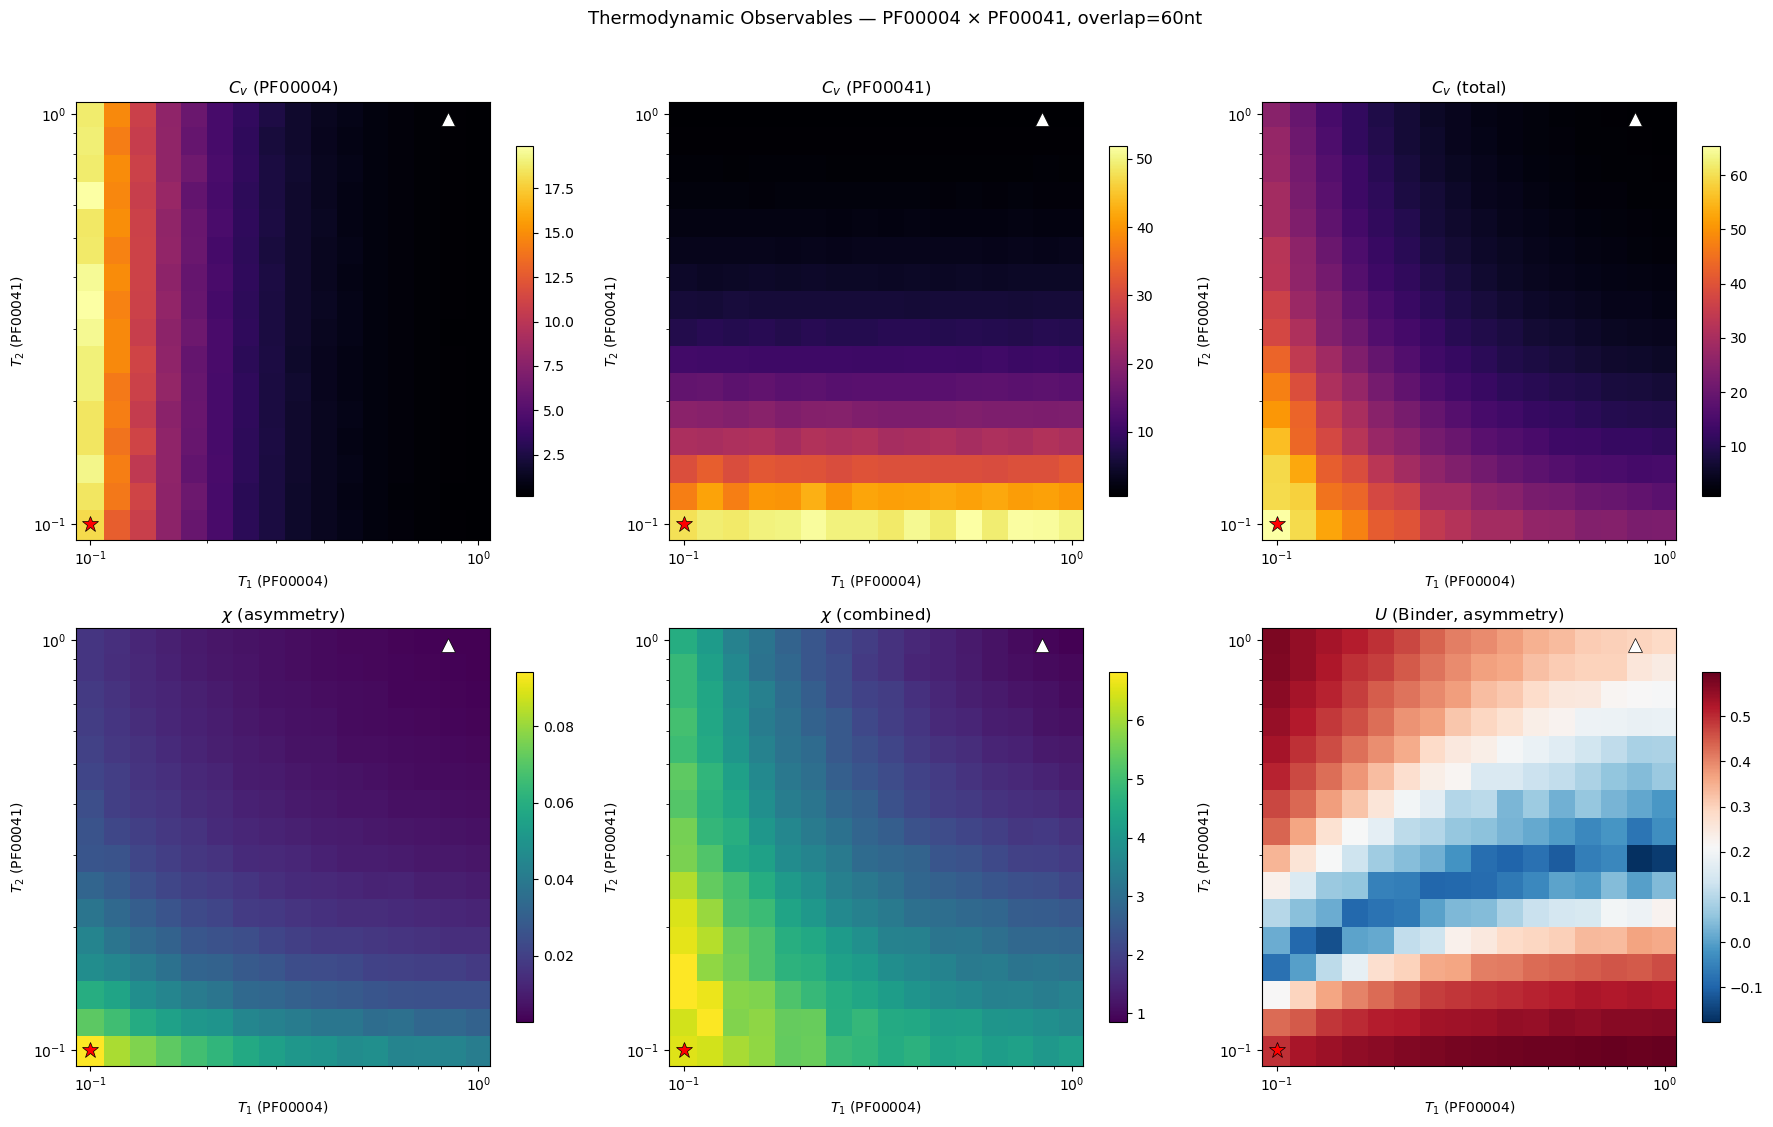

In [41]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(f"Thermodynamic Observables — {PF1} × {PF2}, overlap={overlap}nt",
             fontsize=13, y=1.02)

grids = [
    (obs_coarse['Cv1'], f"$C_v$ ({PF1})", "inferno"),
    (obs_coarse['Cv2'], f"$C_v$ ({PF2})", "inferno"),
    (obs_coarse['Cv_total'], "$C_v$ (total)", "inferno"),
    (obs_coarse['chi_asym'], r"$\chi$ (asymmetry)", "viridis"),
    (obs_coarse['chi_comb'], r"$\chi$ (combined)", "viridis"),
    (obs_coarse['U_asym'], "$U$ (Binder, asymmetry)", "RdBu_r"),
]

for ax, (grid, title, cmap) in zip(axes.flat, grids):
    pcm = ax.pcolormesh(T1_fine, T2_fine, grid, cmap=cmap, shading="auto")
    fig.colorbar(pcm, ax=ax, shrink=0.8)
    ax.set_xlabel(f"$T_1$ ({PF1})")
    ax.set_ylabel(f"$T_2$ ({PF2})")
    ax.set_title(title)
    ax.set_xscale('log')
    ax.set_yscale('log')

    # Mark Cv peak
    ax.plot(T1_peak, T2_peak, "r*", markersize=12,
            markeredgecolor="k", markeredgewidth=0.5)

    # Mark optimal temperatures
    if PF1 in optimal_temps and PF2 in optimal_temps:
        ax.plot(optimal_temps[PF1], optimal_temps[PF2], "w^",
                markersize=10, markeredgecolor="k", markeredgewidth=0.5)

plt.tight_layout()
plt.savefig("coarse_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

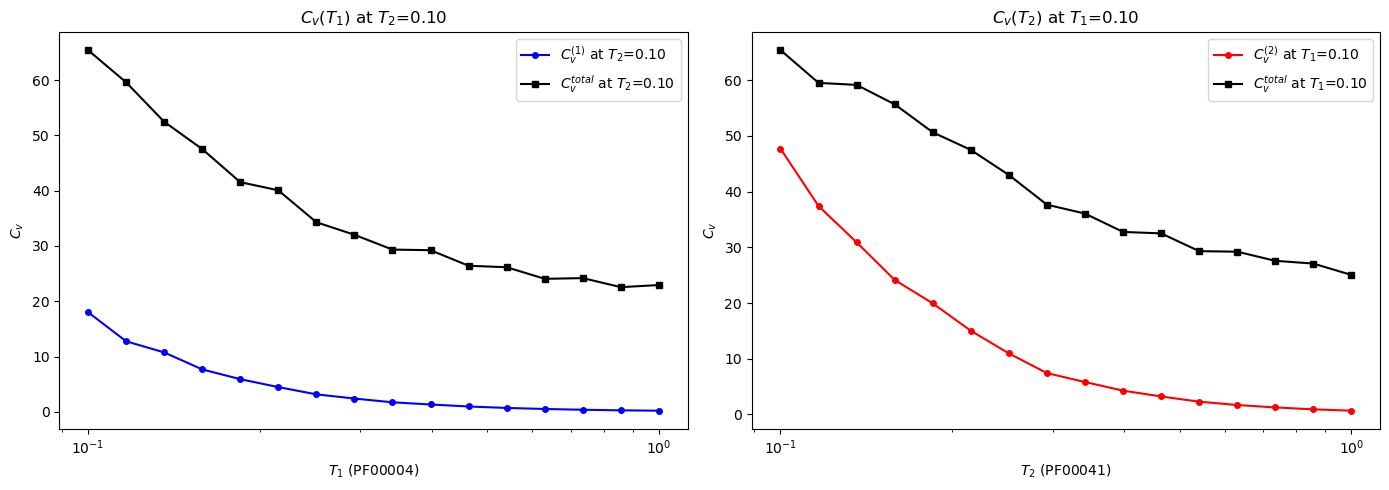

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ─── Cv(T1) at best T2 ───
i_best_T2 = peak_idx[0]
Cv1_slice = obs_coarse['Cv1'][i_best_T2, :]
Cv_total_slice_T1 = obs_coarse['Cv_total'][i_best_T2, :]

axes[0].plot(T1_fine, Cv1_slice, 'b-o', markersize=4,
             label=f"$C_v^{{(1)}}$ at $T_2$={T2_peak:.2f}")
axes[0].plot(T1_fine, Cv_total_slice_T1, 'k-s', markersize=4,
             label=f"$C_v^{{total}}$ at $T_2$={T2_peak:.2f}")

# Peak detection
pk_idx, pk_T, pk_Cv = find_cv_peaks_1d(Cv_total_slice_T1, T1_fine)
for t, c in zip(pk_T, pk_Cv):
    axes[0].axvline(t, color='red', linestyle='--', alpha=0.5)
    axes[0].annotate(f"$T_1$={t:.2f}", (t, c),
                     textcoords="offset points", xytext=(5, 10))

axes[0].set_xlabel(f"$T_1$ ({PF1})")
axes[0].set_ylabel("$C_v$")
axes[0].set_title(f"$C_v(T_1)$ at $T_2$={T2_peak:.2f}")
axes[0].set_xscale('log')
axes[0].legend()

# ─── Cv(T2) at best T1 ───
j_best_T1 = peak_idx[1]
Cv2_slice = obs_coarse['Cv2'][:, j_best_T1]
Cv_total_slice_T2 = obs_coarse['Cv_total'][:, j_best_T1]

axes[1].plot(T2_fine, Cv2_slice, 'r-o', markersize=4,
             label=f"$C_v^{{(2)}}$ at $T_1$={T1_peak:.2f}")
axes[1].plot(T2_fine, Cv_total_slice_T2, 'k-s', markersize=4,
             label=f"$C_v^{{total}}$ at $T_1$={T1_peak:.2f}")

pk_idx2, pk_T2, pk_Cv2 = find_cv_peaks_1d(Cv_total_slice_T2, T2_fine)
for t, c in zip(pk_T2, pk_Cv2):
    axes[1].axvline(t, color='red', linestyle='--', alpha=0.5)
    axes[1].annotate(f"$T_2$={t:.2f}", (t, c),
                     textcoords="offset points", xytext=(5, 10))

axes[1].set_xlabel(f"$T_2$ ({PF2})")
axes[1].set_ylabel("$C_v$")
axes[1].set_title(f"$C_v(T_2)$ at $T_1$={T1_peak:.2f}")
axes[1].set_xscale('log')
axes[1].legend()

plt.tight_layout()
plt.savefig("coarse_1d_slices.png", dpi=150, bbox_inches="tight")
plt.show()

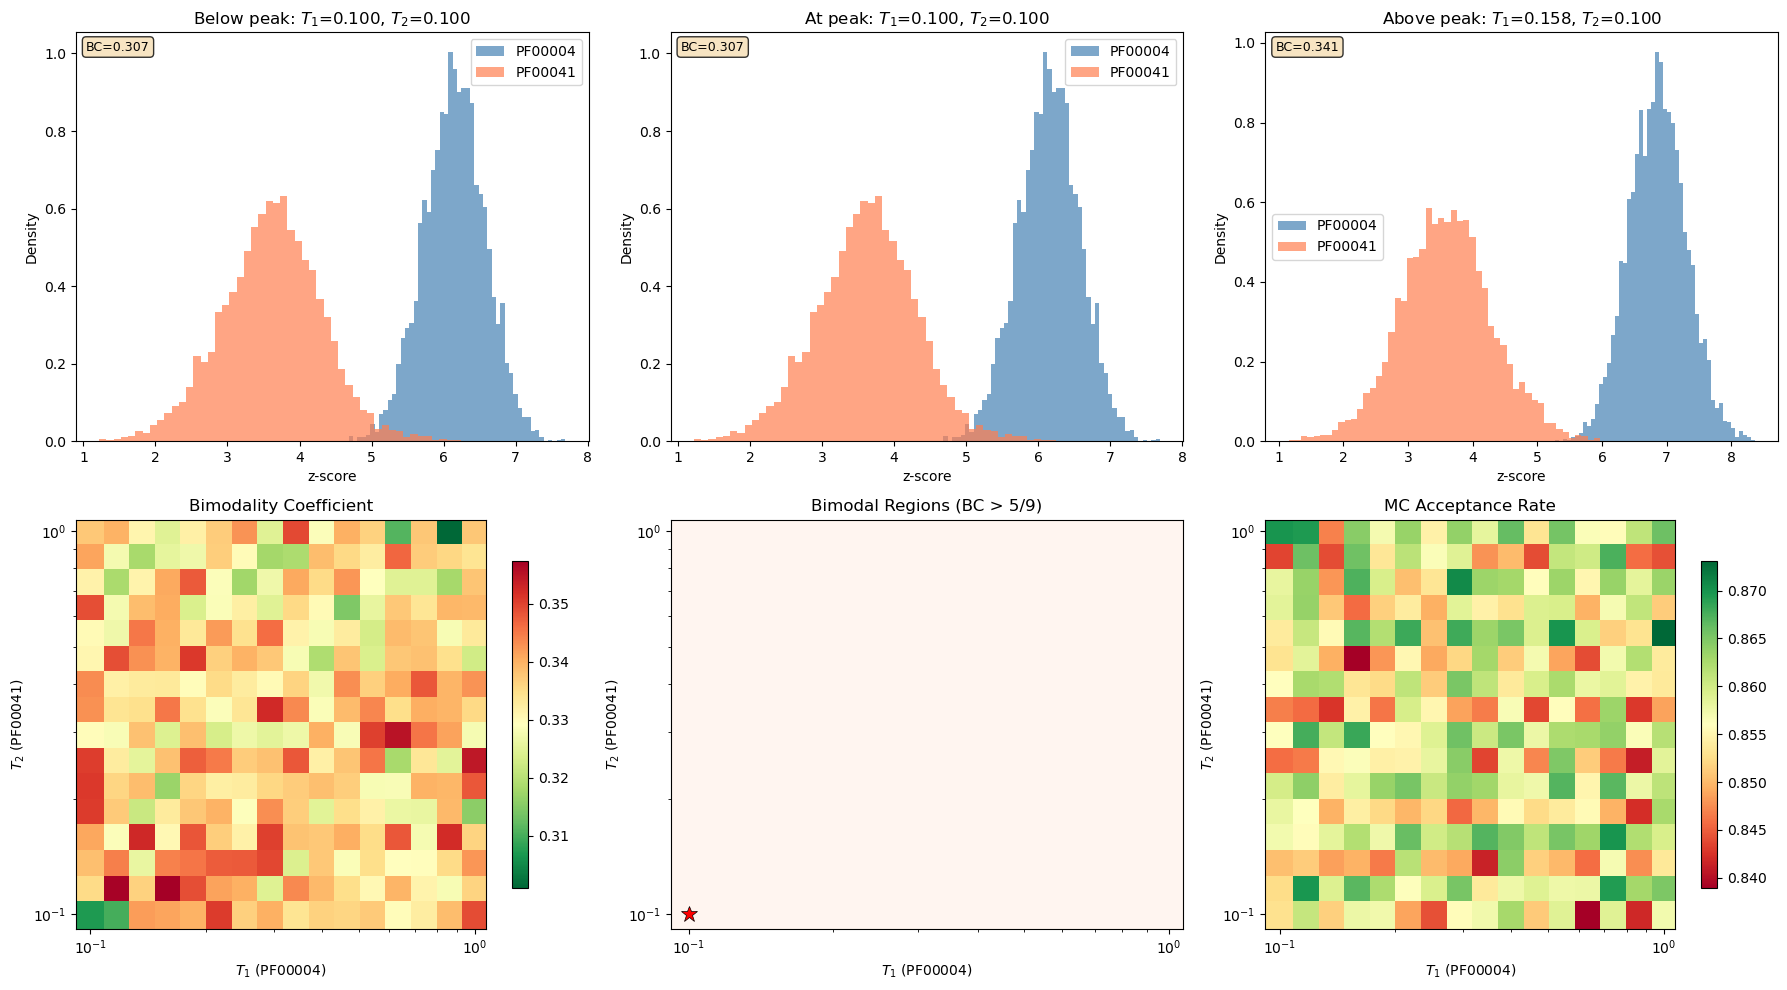

In [43]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ─── Row 1: Energy distributions at 3 temperatures ───
j_below = max(0, peak_idx[1] - 3)
j_at = peak_idx[1]
j_above = min(N_T_FINE - 1, peak_idx[1] + 3)
i_at = peak_idx[0]

T1_vals = [T1_fine[j_below], T1_fine[j_at], T1_fine[j_above]]
j_vals = [j_below, j_at, j_above]
labels = ["Below peak", "At peak", "Above peak"]

for col, (j, T1_val, label) in enumerate(zip(j_vals, T1_vals, labels)):
    z1 = (E1_coarse[i_at, j] - d1['mean']) / d1['std']
    z2 = (E2_coarse[i_at, j] - d2['mean']) / d2['std']

    axes[0, col].hist(z1, bins=50, density=True, alpha=0.7,
                      color='steelblue', label=PF1)
    axes[0, col].hist(z2, bins=50, density=True, alpha=0.7,
                      color='coral', label=PF2)
    axes[0, col].set_xlabel("z-score")
    axes[0, col].set_ylabel("Density")
    axes[0, col].set_title(f"{label}: $T_1$={T1_val:.3f}, $T_2$={T2_peak:.3f}")
    axes[0, col].legend()

    bc = bimodality_coefficient(z1 + z2)
    axes[0, col].text(0.02, 0.98, f"BC={bc:.3f}",
                      transform=axes[0, col].transAxes, va='top', fontsize=9,
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# ─── Row 2: Bimodality heatmap, bimodal regions, acceptance rates ───
pcm0 = axes[1, 0].pcolormesh(T1_fine, T2_fine, obs_coarse['BC'],
                              cmap="RdYlGn_r", shading="auto")
axes[1, 0].set_xlabel(f"$T_1$ ({PF1})")
axes[1, 0].set_ylabel(f"$T_2$ ({PF2})")
axes[1, 0].set_title("Bimodality Coefficient")
axes[1, 0].set_xscale('log')
axes[1, 0].set_yscale('log')
fig.colorbar(pcm0, ax=axes[1, 0], shrink=0.8)

bc_mask = obs_coarse['BC'] > 5/9
axes[1, 1].pcolormesh(T1_fine, T2_fine, bc_mask.astype(float),
                       cmap="Reds", shading="auto", vmin=0, vmax=1)
axes[1, 1].set_xlabel(f"$T_1$ ({PF1})")
axes[1, 1].set_ylabel(f"$T_2$ ({PF2})")
axes[1, 1].set_title("Bimodal Regions (BC > 5/9)")
axes[1, 1].set_xscale('log')
axes[1, 1].set_yscale('log')
axes[1, 1].plot(T1_peak, T2_peak, "r*", markersize=12,
                markeredgecolor="k", markeredgewidth=0.5)

pcm2 = axes[1, 2].pcolormesh(T1_fine, T2_fine, acc_coarse,
                              cmap="RdYlGn", shading="auto")
fig.colorbar(pcm2, ax=axes[1, 2], shrink=0.8)
axes[1, 2].set_xlabel(f"$T_1$ ({PF1})")
axes[1, 2].set_ylabel(f"$T_2$ ({PF2})")
axes[1, 2].set_title("MC Acceptance Rate")
axes[1, 2].set_xscale('log')
axes[1, 2].set_yscale('log')

plt.tight_layout()
plt.savefig("coarse_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [44]:
# ─── Identify peak region, define refined scan box ───
# With geometric spacing, the coarse grid spacing varies with T.
# Use log-space spacing to define the box around the peak.
log_dT = (np.log10(T_MAX) - np.log10(T_MIN)) / (N_T_FINE - 1)

# Box: peak × 10^(±2 log_dT)  →  ± 2 coarse grid spacings in log-space
T1_ref_min = max(T_MIN, T1_peak * 10**(-2 * log_dT))
T1_ref_max = min(T_MAX, T1_peak * 10**(+2 * log_dT))
T2_ref_min = max(T_MIN, T2_peak * 10**(-2 * log_dT))
T2_ref_max = min(T_MAX, T2_peak * 10**(+2 * log_dT))

print(f"Coarse log-spacing: d(log10 T) = {log_dT:.4f}")
print(f"Cv_total peak: T1={T1_peak:.3f}, T2={T2_peak:.3f}")
print(f"Refined scan box:")
print(f"  T1: [{T1_ref_min:.4f}, {T1_ref_max:.4f}]")
print(f"  T2: [{T2_ref_min:.4f}, {T2_ref_max:.4f}]")
print(f"  Fine grid: {N_T_FINE_REFINED}x{N_T_FINE_REFINED}, {N_RUNS_REFINED} stagger runs")

Coarse log-spacing: d(log10 T) = 0.0667
Cv_total peak: T1=0.100, T2=0.100
Refined scan box:
  T1: [0.1000, 0.1359]
  T2: [0.1000, 0.1359]
  Fine grid: 24x24, 9 stagger runs


In [45]:
# ─── Build refined fine grids ───
T1_ref_fine = np.linspace(T1_ref_min, T1_ref_max, N_T_FINE_REFINED)
T2_ref_fine = np.linspace(T2_ref_min, T2_ref_max, N_T_FINE_REFINED)

# ─── Pre-allocate ───
E1_refined = np.full((N_T_FINE_REFINED, N_T_FINE_REFINED, SAMPLES_REFINED), np.nan)
E2_refined = np.full((N_T_FINE_REFINED, N_T_FINE_REFINED, SAMPLES_REFINED), np.nan)
acc_refined = np.full((N_T_FINE_REFINED, N_T_FINE_REFINED), np.nan)
refined_diagnostics = []

t_start = time.time()
run_count = 0

for a in range(N_STAGGER_REFINED):
    for b in range(N_STAGGER_REFINED):
        run_count += 1
        seed = SEED_BASE + 100 + a * N_STAGGER_REFINED + b

        T1_sub = T1_ref_fine[a::N_STAGGER_REFINED]
        T2_sub = T2_ref_fine[b::N_STAGGER_REFINED]

        print(f"\n--- Refined run {run_count}/{N_RUNS_REFINED} "
              f"(a={a}, b={b}, seed={seed}) ---")
        np.random.seed(seed)

        result = run_2d_replica_exchange(
            DCA_1, DCA_2,
            d1['aa_len'], d2['aa_len'], overlap,
            T1_grid=T1_sub, T2_grid=T2_sub,
            n_burnin=BURNIN, n_samples=SAMPLES_REFINED,
            sample_interval=SAMPLE_INTERVAL, swap_interval=SWAP_INTERVAL,
            nat_std1=d1['std'], nat_std2=d2['std'],
        )

        for i in range(N_T_REFINED):
            for j in range(N_T_REFINED):
                i_fine = b + i * N_STAGGER_REFINED
                j_fine = a + j * N_STAGGER_REFINED
                E1_refined[i_fine, j_fine, :] = result['E1_grid'][i, j]
                E2_refined[i_fine, j_fine, :] = result['E2_grid'][i, j]
                acc_refined[i_fine, j_fine] = result['acceptance_grid'][i, j]

        refined_diagnostics.append({
            'a': a, 'b': b,
            'swap_h': np.mean(result['swap_rates_h']),
            'swap_v': np.mean(result['swap_rates_v']),
            'elapsed': result['elapsed_time'],
        })

elapsed_refined = time.time() - t_start
assert not np.any(np.isnan(E1_refined[:, :, 0])), "Refined grid not fully filled!"

print(f"\nRefined scan complete: {elapsed_refined:.1f}s total")
print(f"Mean swap rates — H: {np.mean([d['swap_h'] for d in refined_diagnostics]):.3f}, "
      f"V: {np.mean([d['swap_v'] for d in refined_diagnostics]):.3f}")


--- Refined run 1/9 (a=0, b=0, seed=142) ---
2D RE: 8x8 = 64 replicas
  T1 range: [0.100, 0.133]
  T2 range: [0.100, 0.133]
  Burn-in: 200000, Samples: 20000, Sample interval: 100, Swap interval: 50


2D RE: 100%|██████████| 2200000/2200000 [00:18<00:00, 121414.29step/s]

2D RE completed in 18.12s (20000 samples collected)
  Mean swap rate H: 0.913, V: 0.855

--- Refined run 2/9 (a=0, b=1, seed=143) ---
2D RE: 8x8 = 64 replicas
  T1 range: [0.100, 0.133]
  T2 range: [0.102, 0.134]
  Burn-in: 200000, Samples: 20000, Sample interval: 100, Swap interval: 50



2D RE: 100%|██████████| 2200000/2200000 [00:17<00:00, 127247.43step/s]

2D RE completed in 17.29s (20000 samples collected)
  Mean swap rate H: 0.913, V: 0.858

--- Refined run 3/9 (a=0, b=2, seed=144) ---
2D RE: 8x8 = 64 replicas
  T1 range: [0.100, 0.133]
  T2 range: [0.103, 0.136]
  Burn-in: 200000, Samples: 20000, Sample interval: 100, Swap interval: 50


...

2D RE completed in 17.92s (20000 samples collected)
  Mean swap rate H: 0.917, V: 0.855

--- Refined run 8/9 (a=2, b=1, seed=149) ---
2D RE: 8x8 = 64 replicas
  T1 range: [0.103, 0.136]
  T2 range: [0.102, 0.134]
  Burn-in: 200000, Samples: 20000, Sample interval: 100, Swap interval: 50



2D RE: 100%|██████████| 2200000/2200000 [00:17<00:00, 127289.16step/s]

2D RE completed in 17.29s (20000 samples collected)
  Mean swap rate H: 0.917, V: 0.858

--- Refined run 9/9 (a=2, b=2, seed=150) ---
2D RE: 8x8 = 64 replicas
  T1 range: [0.103, 0.136]
  T2 range: [0.103, 0.136]
  Burn-in: 200000, Samples: 20000, Sample interval: 100, Swap interval: 50



2D RE: 100%|██████████| 2200000/2200000 [00:17<00:00, 123993.31step/s]

2D RE completed in 17.74s (20000 samples collected)
  Mean swap rate H: 0.918, V: 0.861

Refined scan complete: 156.8s total
Mean swap rates — H: 0.915, V: 0.858


In [46]:
obs_refined = compute_all_observables(
    E1_refined, E2_refined, T1_ref_fine, T2_ref_fine,
    d1['mean'], d1['std'], d2['mean'], d2['std'])

# ─── Block bootstrap errors on refined grid ───
nT2r, nT1r = N_T_FINE_REFINED, N_T_FINE_REFINED
Cv_total_err = np.zeros((nT2r, nT1r))
chi_asym_err = np.zeros((nT2r, nT1r))

for i in range(nT2r):
    for j in range(nT1r):
        T1 = T1_ref_fine[j]
        T2 = T2_ref_fine[i]
        T_eff = 2.0 / (1.0/T1 + 1.0/T2)

        z1 = (E1_refined[i, j] - d1['mean']) / d1['std']
        z2 = (E2_refined[i, j] - d2['mean']) / d2['std']
        z_total = z1 + z2

        T_eff_local = T_eff  # capture for lambda
        Cv_total_err[i, j] = block_bootstrap_error(
            z_total, lambda s, T=T_eff_local: np.var(s) / T**2
        )

        asym, _, _ = compute_order_parameters(z1, z2)
        chi_asym_err[i, j] = block_bootstrap_error(
            asym, lambda s, T=T_eff_local: np.var(s) / T
        )

# Peak location on refined grid
peak_ref = np.unravel_index(
    np.argmax(obs_refined['Cv_total']), obs_refined['Cv_total'].shape)
T2_peak_ref = T2_ref_fine[peak_ref[0]]
T1_peak_ref = T1_ref_fine[peak_ref[1]]

print(f"Refined Cv_total peak: T1={T1_peak_ref:.4f}, T2={T2_peak_ref:.4f}")
print(f"  Cv_total = {obs_refined['Cv_total'][peak_ref]:.6f} "
      f"\u00b1 {Cv_total_err[peak_ref]:.6f}")

Refined Cv_total peak: T1=0.1000, T2=0.1016
  Cv_total = 69.975139 ± 2.914840


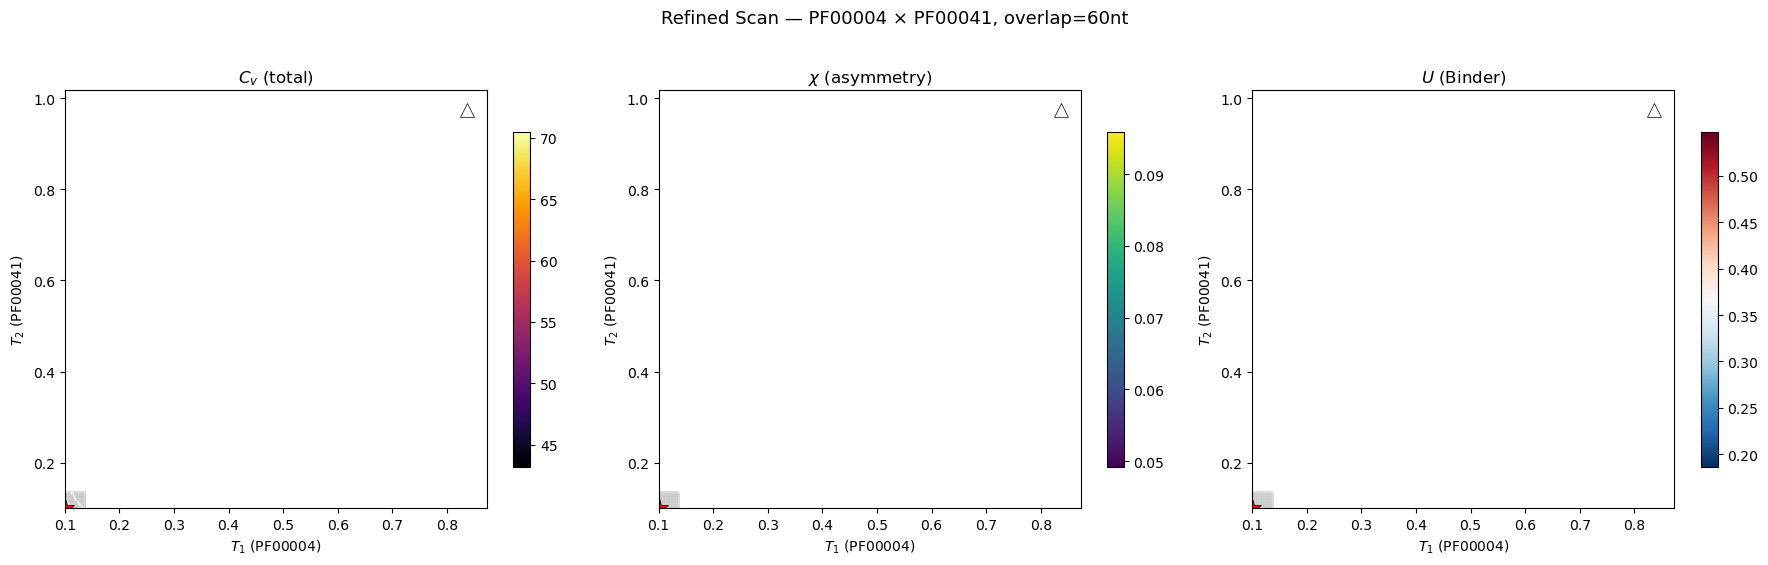

In [47]:
from scipy.interpolate import RegularGridInterpolator

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle(f"Refined Scan — {PF1} × {PF2}, overlap={overlap}nt",
             fontsize=13, y=1.02)

# Interpolation grid for smooth rendering
T1_plot = np.linspace(T1_ref_min, T1_ref_max, 200)
T2_plot = np.linspace(T2_ref_min, T2_ref_max, 200)
T1_mesh, T2_mesh = np.meshgrid(T1_plot, T2_plot)
query = np.column_stack([T2_mesh.ravel(), T1_mesh.ravel()])

plot_specs = [
    (obs_refined['Cv_total'], "$C_v$ (total)", "inferno"),
    (obs_refined['chi_asym'], r"$\chi$ (asymmetry)", "viridis"),
    (obs_refined['U_asym'], "$U$ (Binder)", "RdBu_r"),
]

for ax, (grid, title, cmap) in zip(axes, plot_specs):
    interp = RegularGridInterpolator(
        (T2_ref_fine, T1_ref_fine), grid, method='cubic', bounds_error=False)
    grid_fine = interp(query).reshape(T2_mesh.shape)

    pcm = ax.pcolormesh(T1_plot, T2_plot, grid_fine, cmap=cmap, shading="auto")
    fig.colorbar(pcm, ax=ax, shrink=0.8)

    # Contour lines at 50%, 75%, 90% of peak for Cv
    if "C_v" in title:
        peak_val = np.nanmax(grid_fine)
        levels = [0.5 * peak_val, 0.75 * peak_val, 0.9 * peak_val]
        ax.contour(T1_plot, T2_plot, grid_fine, levels=levels,
                   colors='white', linewidths=0.8, linestyles=[':', '--', '-'])

    # Mark peak and optimal temps
    ax.plot(T1_peak_ref, T2_peak_ref, "r*", markersize=14,
            markeredgecolor="k", markeredgewidth=0.5)
    if PF1 in optimal_temps and PF2 in optimal_temps:
        ax.plot(optimal_temps[PF1], optimal_temps[PF2], "w^",
                markersize=10, markeredgecolor="k", markeredgewidth=0.5)

    # Overlay sample grid points
    T1_pts, T2_pts = np.meshgrid(T1_ref_fine, T2_ref_fine)
    ax.scatter(T1_pts.ravel(), T2_pts.ravel(), c='white', s=4, alpha=0.3,
               edgecolors='gray', linewidths=0.2)

    ax.set_xlabel(f"$T_1$ ({PF1})")
    ax.set_ylabel(f"$T_2$ ({PF2})")
    ax.set_title(title)

plt.tight_layout()
plt.savefig("refined_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

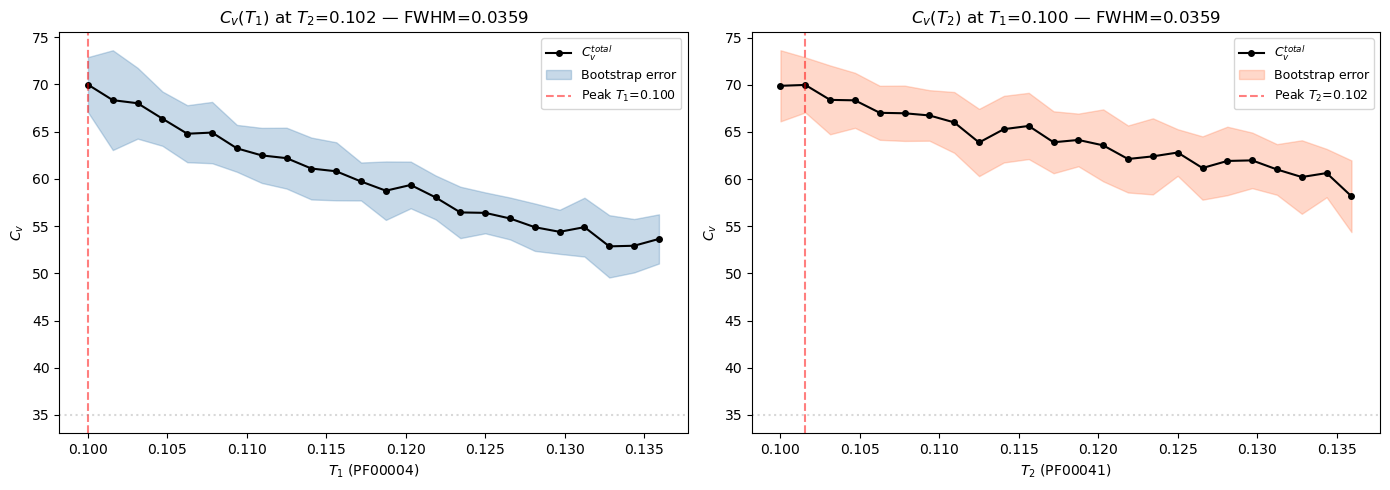

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ─── Cv_total(T1) at best T2 ───
i_best = peak_ref[0]
Cv_slice = obs_refined['Cv_total'][i_best, :]
Cv_err_slice = Cv_total_err[i_best, :]

axes[0].plot(T1_ref_fine, Cv_slice, 'k-o', markersize=4, label="$C_v^{total}$")
axes[0].fill_between(T1_ref_fine, Cv_slice - Cv_err_slice, Cv_slice + Cv_err_slice,
                     alpha=0.3, color='steelblue', label="Bootstrap error")
axes[0].axvline(T1_peak_ref, color='red', linestyle='--', alpha=0.5,
                label=f"Peak $T_1$={T1_peak_ref:.3f}")

# FWHM
half_max = np.max(Cv_slice) / 2
above_half = T1_ref_fine[Cv_slice >= half_max]
if len(above_half) >= 2:
    fwhm = above_half[-1] - above_half[0]
    axes[0].axhline(half_max, color='gray', linestyle=':', alpha=0.3)
    axes[0].set_title(f"$C_v(T_1)$ at $T_2$={T2_peak_ref:.3f} — FWHM={fwhm:.4f}")
else:
    axes[0].set_title(f"$C_v(T_1)$ at $T_2$={T2_peak_ref:.3f}")

axes[0].set_xlabel(f"$T_1$ ({PF1})")
axes[0].set_ylabel("$C_v$")
axes[0].legend(fontsize=9)

# ─── Cv_total(T2) at best T1 ───
j_best = peak_ref[1]
Cv_slice2 = obs_refined['Cv_total'][:, j_best]
Cv_err_slice2 = Cv_total_err[:, j_best]

axes[1].plot(T2_ref_fine, Cv_slice2, 'k-o', markersize=4, label="$C_v^{total}$")
axes[1].fill_between(T2_ref_fine, Cv_slice2 - Cv_err_slice2, Cv_slice2 + Cv_err_slice2,
                     alpha=0.3, color='coral', label="Bootstrap error")
axes[1].axvline(T2_peak_ref, color='red', linestyle='--', alpha=0.5,
                label=f"Peak $T_2$={T2_peak_ref:.3f}")

above_half2 = T2_ref_fine[Cv_slice2 >= np.max(Cv_slice2) / 2]
if len(above_half2) >= 2:
    fwhm2 = above_half2[-1] - above_half2[0]
    axes[1].axhline(np.max(Cv_slice2) / 2, color='gray', linestyle=':', alpha=0.3)
    axes[1].set_title(f"$C_v(T_2)$ at $T_1$={T1_peak_ref:.3f} — FWHM={fwhm2:.4f}")
else:
    axes[1].set_title(f"$C_v(T_2)$ at $T_1$={T1_peak_ref:.3f}")

axes[1].set_xlabel(f"$T_2$ ({PF2})")
axes[1].set_ylabel("$C_v$")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("refined_1d_cuts.png", dpi=150, bbox_inches="tight")
plt.show()

## Part 4: Systematic Multi-Pair Analysis

Repeat the coarse → refined scan across **4 pairs × 3 overlap lengths** to check:

- **Universality**: Do $C_v$ peaks appear in the same $(T_1, T_2)$ region regardless of protein pair?
- **Finite-size scaling**: Does peak height grow with overlap length (analogous to system size)?
- **Binder crossing**: Do Binder cumulants at different overlaps cross at a single $T_c$?

In [49]:
import pickle

os.makedirs(CHECKPOINT_DIR, exist_ok=True)


def compute_overlaps(L1, L2):
    """Compute small/medium/large overlap lengths (multiples of 3, frame 0).
    Minimum overlap is 18 nt (6 codons) to satisfy initial_seq_no_stops
    internal constraint: lengthmidoverlap = (overlap - 12) / 3 >= 2.
    """
    max_ovlp = min(3 * L1, 3 * L2) - 6
    max_ovlp = min(max_ovlp, 90)
    max_ovlp = (max_ovlp // 3) * 3
    mid_ovlp = max(18, (max_ovlp // 2 // 3) * 3)
    return [18, mid_ovlp, max_ovlp]


def run_coarse_scan(DCA_1, DCA_2, d1, d2, ovlp):
    """Run coarse staggered 2D RE scan. Returns (E1, E2, acc, T1, T2)."""
    T1_f = np.geomspace(T_MIN, T_MAX, N_T_FINE)
    T2_f = np.geomspace(T_MIN, T_MAX, N_T_FINE)
    E1 = np.full((N_T_FINE, N_T_FINE, SAMPLES_COARSE), np.nan)
    E2 = np.full((N_T_FINE, N_T_FINE, SAMPLES_COARSE), np.nan)
    acc = np.full((N_T_FINE, N_T_FINE), np.nan)

    for a in range(N_STAGGER):
        for b in range(N_STAGGER):
            seed = SEED_BASE + 200 + a * N_STAGGER + b
            np.random.seed(seed)
            result = run_2d_replica_exchange(
                DCA_1, DCA_2, d1['aa_len'], d2['aa_len'], ovlp,
                T1_grid=T1_f[a::N_STAGGER], T2_grid=T2_f[b::N_STAGGER],
                n_burnin=BURNIN, n_samples=SAMPLES_COARSE,
                sample_interval=SAMPLE_INTERVAL, swap_interval=SWAP_INTERVAL,
                nat_std1=d1['std'], nat_std2=d2['std'],
            )
            for i in range(N_T):
                for j in range(N_T):
                    E1[b + i*N_STAGGER, a + j*N_STAGGER] = result['E1_grid'][i, j]
                    E2[b + i*N_STAGGER, a + j*N_STAGGER] = result['E2_grid'][i, j]
                    acc[b + i*N_STAGGER, a + j*N_STAGGER] = result['acceptance_grid'][i, j]
    return E1, E2, acc, T1_f, T2_f


def run_refined_scan(DCA_1, DCA_2, d1, d2, ovlp, T1_ctr, T2_ctr, dT_spacing):
    """Run refined staggered 2D RE scan around (T1_ctr, T2_ctr).
    Uses linspace for the zoomed region (narrow range where linear ≈ geometric).
    """
    T1_lo = max(T_MIN, T1_ctr - 2 * dT_spacing)
    T1_hi = min(T_MAX, T1_ctr + 2 * dT_spacing)
    T2_lo = max(T_MIN, T2_ctr - 2 * dT_spacing)
    T2_hi = min(T_MAX, T2_ctr + 2 * dT_spacing)

    T1_f = np.linspace(T1_lo, T1_hi, N_T_FINE_REFINED)
    T2_f = np.linspace(T2_lo, T2_hi, N_T_FINE_REFINED)
    E1 = np.full((N_T_FINE_REFINED, N_T_FINE_REFINED, SAMPLES_REFINED), np.nan)
    E2 = np.full((N_T_FINE_REFINED, N_T_FINE_REFINED, SAMPLES_REFINED), np.nan)
    acc = np.full((N_T_FINE_REFINED, N_T_FINE_REFINED), np.nan)

    for a in range(N_STAGGER_REFINED):
        for b in range(N_STAGGER_REFINED):
            seed = SEED_BASE + 300 + a * N_STAGGER_REFINED + b
            np.random.seed(seed)
            result = run_2d_replica_exchange(
                DCA_1, DCA_2, d1['aa_len'], d2['aa_len'], ovlp,
                T1_grid=T1_f[a::N_STAGGER_REFINED],
                T2_grid=T2_f[b::N_STAGGER_REFINED],
                n_burnin=BURNIN, n_samples=SAMPLES_REFINED,
                sample_interval=SAMPLE_INTERVAL, swap_interval=SWAP_INTERVAL,
                nat_std1=d1['std'], nat_std2=d2['std'],
            )
            for i in range(N_T_REFINED):
                for j in range(N_T_REFINED):
                    E1[b + i*N_STAGGER_REFINED, a + j*N_STAGGER_REFINED] = result['E1_grid'][i, j]
                    E2[b + i*N_STAGGER_REFINED, a + j*N_STAGGER_REFINED] = result['E2_grid'][i, j]
                    acc[b + i*N_STAGGER_REFINED, a + j*N_STAGGER_REFINED] = result['acceptance_grid'][i, j]
    return E1, E2, acc, T1_f, T2_f


# ─── Main loop ───
all_results = {}
# For refined scan box sizing, compute spacing in log-space
log_spacing = (np.log10(T_MAX) - np.log10(T_MIN)) / (N_T_FINE - 1)

for pair_idx, (PF_A, PF_B) in enumerate(PAIRS):
    dA, dB = family_data[PF_A], family_data[PF_B]
    DCA_A = [dA['Js'], dA['hs']]
    DCA_B = [dB['Js'], dB['hs']]
    overlaps = compute_overlaps(dA['aa_len'], dB['aa_len'])

    print(f"\n{'='*60}")
    print(f"Pair {pair_idx+1}/{len(PAIRS)}: {PF_A} x {PF_B}, overlaps={overlaps}")
    print(f"{'='*60}")

    for ovlp in overlaps:
        key = f"{PF_A}_{PF_B}_{ovlp}"
        print(f"\n  Overlap = {ovlp} nt")

        # Coarse scan
        print("  -> Coarse scan...")
        E1_c, E2_c, acc_c, T1_c, T2_c = run_coarse_scan(
            DCA_A, DCA_B, dA, dB, ovlp)
        obs_c = compute_all_observables(
            E1_c, E2_c, T1_c, T2_c,
            dA['mean'], dA['std'], dB['mean'], dB['std'])

        # Find peak
        pk = np.unravel_index(
            np.argmax(obs_c['Cv_total']), obs_c['Cv_total'].shape)
        T1_pk, T2_pk = T1_c[pk[1]], T2_c[pk[0]]
        print(f"  -> Cv peak at T1={T1_pk:.3f}, T2={T2_pk:.3f}")

        # Refined scan: box ± 2 coarse spacings (in linear T around peak)
        dT_box = T1_pk * (10**(2 * log_spacing) - 1)
        print("  -> Refined scan...")
        E1_r, E2_r, acc_r, T1_r, T2_r = run_refined_scan(
            DCA_A, DCA_B, dA, dB, ovlp, T1_pk, T2_pk, dT_box)
        obs_r = compute_all_observables(
            E1_r, E2_r, T1_r, T2_r,
            dA['mean'], dA['std'], dB['mean'], dB['std'])

        pk_r = np.unravel_index(
            np.argmax(obs_r['Cv_total']), obs_r['Cv_total'].shape)
        T1_pk_r, T2_pk_r = T1_r[pk_r[1]], T2_r[pk_r[0]]

        all_results[key] = {
            'PF_A': PF_A, 'PF_B': PF_B, 'overlap': ovlp,
            'coarse': {'obs': obs_c, 'T1': T1_c, 'T2': T2_c,
                       'peak_T1': T1_pk, 'peak_T2': T2_pk},
            'refined': {'obs': obs_r, 'T1': T1_r, 'T2': T2_r,
                        'peak_T1': T1_pk_r, 'peak_T2': T2_pk_r,
                        'peak_Cv': obs_r['Cv_total'][pk_r]},
        }

        # Checkpoint
        ckpt_path = os.path.join(CHECKPOINT_DIR, "systematic_results.pkl")
        with open(ckpt_path, 'wb') as f:
            pickle.dump(all_results, f)
        print(f"  -> Checkpoint saved ({len(all_results)} configs)")

print(f"\n{'='*60}")
print(f"All {len(all_results)} configurations complete!")


Pair 1/4: PF00004 x PF00041, overlaps=[18, 45, 90]

  Overlap = 18 nt
  -> Coarse scan...
2D RE: 8x8 = 64 replicas
  T1 range: [0.100, 0.858]
  T2 range: [0.100, 0.858]
  Burn-in: 200000, Samples: 5000, Sample interval: 100, Swap interval: 50


2D RE: 100%|██████████| 700000/700000 [00:06<00:00, 100593.10step/s]

2D RE completed in 6.96s (5000 samples collected)
  Mean swap rate H: 0.693, V: 0.520
2D RE: 8x8 = 64 replicas
  T1 range: [0.100, 0.858]
  T2 range: [0.117, 1.000]
  Burn-in: 200000, Samples: 5000, Sample interval: 100, Swap interval: 50



2D RE: 100%|██████████| 700000/700000 [00:06<00:00, 114270.33step/s]

2D RE completed in 6.13s (5000 samples collected)
  Mean swap rate H: 0.693, V: 0.573
2D RE: 8x8 = 64 replicas
  T1 range: [0.117, 1.000]
  T2 range: [0.100, 0.858]
  Burn-in: 200000, Samples: 5000, Sample interval: 100, Swap interval: 50


...


2D RE: 100%|██████████| 700000/700000 [00:05<00:00, 129998.75step/s]

2D RE completed in 5.39s (5000 samples collected)
  Mean swap rate H: 0.731, V: 0.571
  -> Cv peak at T1=0.100, T2=0.100


  -> Refined scan...
2D RE: 8x8 = 64 replicas
  T1 range: [0.100, 0.166]
  T2 range: [0.100, 0.166]
  Burn-in: 200000, Samples: 20000, Sample interval: 100, Swap interval: 50


2D RE:  76%|███████▌  | 1662100/2200000 [00:16<00:05, 101264.53step/s]


KeyboardInterrupt: 

In [50]:
# ─── Load checkpoint (run this cell to resume from saved state) ───
ckpt_path = os.path.join(CHECKPOINT_DIR, "systematic_results.pkl")

if os.path.exists(ckpt_path):
    with open(ckpt_path, 'rb') as f:
        all_results = pickle.load(f)
    print(f"Loaded {len(all_results)} configurations from checkpoint")
    for key, res in all_results.items():
        r = res['refined']
        print(f"  {res['PF_A']} x {res['PF_B']}, overlap={res['overlap']}: "
              f"peak at T1={r['peak_T1']:.3f}, T2={r['peak_T2']:.3f}, "
              f"Cv={r['peak_Cv']:.4f}")
else:
    print("No checkpoint found — run Cell 17 first")

Loaded 12 configurations from checkpoint
  PF00004 x PF00041, overlap=18: peak at T1=0.100, T2=0.100, Cv=69.7159
  PF00004 x PF00041, overlap=45: peak at T1=0.100, T2=0.104, Cv=68.5265
  PF00004 x PF00041, overlap=90: peak at T1=0.100, T2=0.100, Cv=68.5814
  PF00076 x PF00512, overlap=18: peak at T1=0.103, T2=0.100, Cv=81.1098
  PF00076 x PF00512, overlap=45: peak at T1=0.100, T2=0.104, Cv=80.0194
  PF00076 x PF00512, overlap=90: peak at T1=0.100, T2=0.100, Cv=85.9324
  PF00096 x PF00004, overlap=18: peak at T1=0.967, T2=0.100, Cv=362.5207
  PF00096 x PF00004, overlap=30: peak at T1=0.934, T2=0.100, Cv=415.9075
  PF00096 x PF00004, overlap=63: peak at T1=0.969, T2=0.100, Cv=416.3364
  PF00397 x PF00072, overlap=18: peak at T1=0.411, T2=0.100, Cv=126.9613
  PF00397 x PF00072, overlap=39: peak at T1=0.490, T2=0.100, Cv=128.6167
  PF00397 x PF00072, overlap=78: peak at T1=0.537, T2=0.100, Cv=123.1022


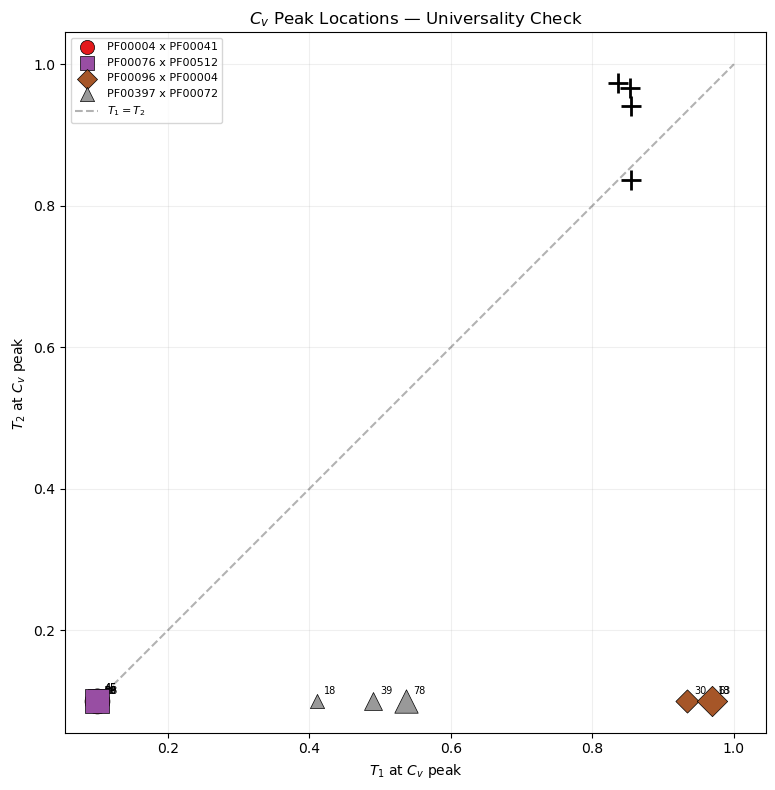

In [51]:
fig, ax = plt.subplots(figsize=(8, 8))

pair_colors = plt.cm.Set1(np.linspace(0, 1, len(PAIRS)))
pair_markers = ['o', 's', 'D', '^']

for pair_idx, ((PF_A, PF_B), color, marker) in enumerate(
        zip(PAIRS, pair_colors, pair_markers)):
    overlaps = compute_overlaps(family_data[PF_A]['aa_len'],
                                family_data[PF_B]['aa_len'])
    first = True
    for ovlp in overlaps:
        key = f"{PF_A}_{PF_B}_{ovlp}"
        if key not in all_results:
            continue
        r = all_results[key]['refined']
        size = 50 + ovlp * 3
        label = f"{PF_A} x {PF_B}" if first else None
        ax.scatter(r['peak_T1'], r['peak_T2'], c=[color], marker=marker,
                   s=size, edgecolors='k', linewidths=0.5, zorder=5,
                   label=label)
        # Annotate overlap
        ax.annotate(f"{ovlp}", (r['peak_T1'], r['peak_T2']),
                    textcoords="offset points", xytext=(5, 5), fontsize=7)
        first = False

# Diagonal reference
ax.plot([T_MIN, T_MAX], [T_MIN, T_MAX], 'k--', alpha=0.3, label="$T_1 = T_2$")

# Optimal temps overlay
for PF_A, PF_B in PAIRS:
    if PF_A in optimal_temps and PF_B in optimal_temps:
        ax.plot(optimal_temps[PF_A], optimal_temps[PF_B], 'k+',
                markersize=15, markeredgewidth=2)

ax.set_xlabel("$T_1$ at $C_v$ peak")
ax.set_ylabel("$T_2$ at $C_v$ peak")
ax.set_title("$C_v$ Peak Locations — Universality Check")
ax.legend(fontsize=8, loc="upper left")
ax.set_aspect('equal')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("cv_peak_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

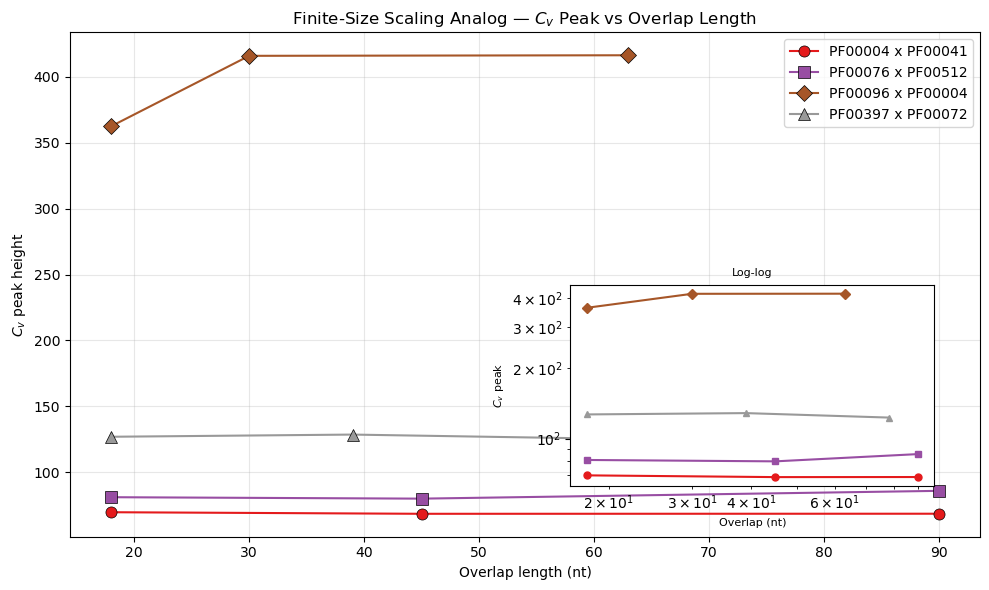

In [52]:
fig, ax = plt.subplots(figsize=(10, 6))

for pair_idx, ((PF_A, PF_B), color, marker) in enumerate(
        zip(PAIRS, pair_colors, pair_markers)):
    overlaps = compute_overlaps(family_data[PF_A]['aa_len'],
                                family_data[PF_B]['aa_len'])
    ovlps_found, peaks_found = [], []
    for ovlp in overlaps:
        key = f"{PF_A}_{PF_B}_{ovlp}"
        if key in all_results:
            ovlps_found.append(ovlp)
            peaks_found.append(all_results[key]['refined']['peak_Cv'])

    if ovlps_found:
        ax.plot(ovlps_found, peaks_found, '-', color=color, marker=marker,
                markersize=8, markeredgecolor='k', markeredgewidth=0.5,
                label=f"{PF_A} x {PF_B}")

ax.set_xlabel("Overlap length (nt)")
ax.set_ylabel("$C_v$ peak height")
ax.set_title("Finite-Size Scaling Analog — $C_v$ Peak vs Overlap Length")
ax.legend()
ax.grid(True, alpha=0.3)

# Log-log inset for scaling exponent
has_data = any(
    sum(1 for ovlp in compute_overlaps(family_data[a]['aa_len'], family_data[b]['aa_len'])
        if f"{a}_{b}_{ovlp}" in all_results) >= 2
    for a, b in PAIRS
)
if has_data:
    ax_inset = ax.inset_axes([0.55, 0.1, 0.4, 0.4])
    for pair_idx, ((PF_A, PF_B), color, marker) in enumerate(
            zip(PAIRS, pair_colors, pair_markers)):
        overlaps = compute_overlaps(family_data[PF_A]['aa_len'],
                                    family_data[PF_B]['aa_len'])
        ovlps_found, peaks_found = [], []
        for ovlp in overlaps:
            key = f"{PF_A}_{PF_B}_{ovlp}"
            if key in all_results:
                ovlps_found.append(ovlp)
                peaks_found.append(all_results[key]['refined']['peak_Cv'])
        if len(ovlps_found) >= 2:
            ax_inset.plot(ovlps_found, peaks_found, '-', color=color,
                          marker=marker, markersize=5)
    ax_inset.set_xscale('log')
    ax_inset.set_yscale('log')
    ax_inset.set_xlabel("Overlap (nt)", fontsize=8)
    ax_inset.set_ylabel("$C_v$ peak", fontsize=8)
    ax_inset.set_title("Log-log", fontsize=8)

plt.tight_layout()
plt.savefig("cv_scaling.png", dpi=150, bbox_inches="tight")
plt.show()

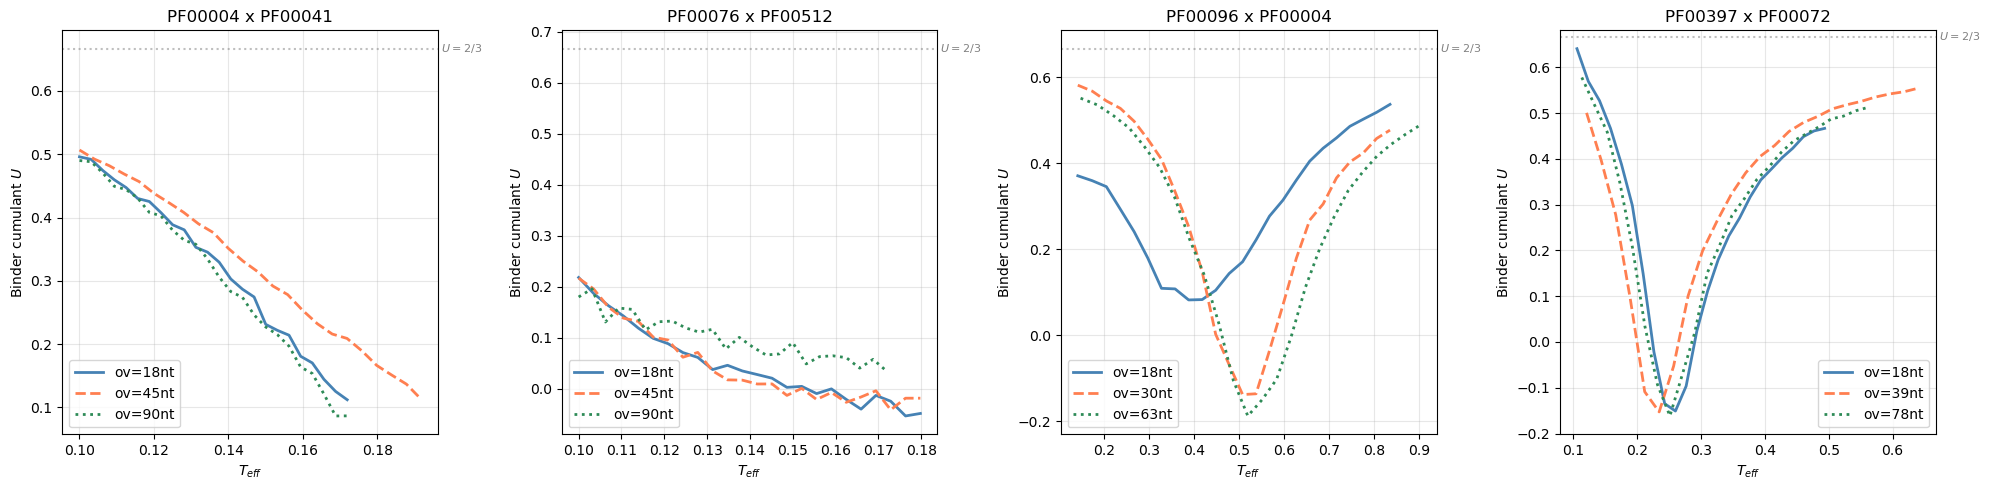

In [53]:
n_pairs = len(PAIRS)
fig, axes = plt.subplots(1, n_pairs, figsize=(5 * n_pairs, 5),
                          squeeze=False)
axes = axes[0]

for ax, (PF_A, PF_B) in zip(axes, PAIRS):
    overlaps = compute_overlaps(family_data[PF_A]['aa_len'],
                                family_data[PF_B]['aa_len'])

    for ovlp, ls, color in zip(overlaps, ['-', '--', ':'],
                                ['steelblue', 'coral', 'seagreen']):
        key = f"{PF_A}_{PF_B}_{ovlp}"
        if key not in all_results:
            continue
        r = all_results[key]['refined']
        T1_r, T2_r = r['T1'], r['T2']
        U = r['obs']['U_asym']

        # 1D cut along diagonal: T1 = T2 = T
        n_diag = min(len(T1_r), len(T2_r))
        T_eff_diag = [2.0 / (1.0/T1_r[idx] + 1.0/T2_r[idx])
                      for idx in range(n_diag)]
        U_diag = [U[idx, idx] for idx in range(n_diag)]

        ax.plot(T_eff_diag, U_diag, ls, linewidth=2, color=color,
                label=f"ov={ovlp}nt")

    ax.set_xlabel("$T_{eff}$")
    ax.set_ylabel("Binder cumulant $U$")
    ax.set_title(f"{PF_A} x {PF_B}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axhline(2/3, color='gray', linestyle=':', alpha=0.5)
    ax.text(ax.get_xlim()[1], 2/3, " $U=2/3$", va='center', fontsize=8,
            color='gray')

plt.tight_layout()
plt.savefig("binder_crossing.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ─── Summary DataFrame ───
rows = []
for key, res in all_results.items():
    r = res['refined']
    c = res['coarse']
    rows.append({
        'Pair': f"{res['PF_A']} x {res['PF_B']}",
        'Overlap (nt)': res['overlap'],
        'Coarse T1_peak': f"{c['peak_T1']:.3f}",
        'Coarse T2_peak': f"{c['peak_T2']:.3f}",
        'Refined T1_peak': f"{r['peak_T1']:.4f}",
        'Refined T2_peak': f"{r['peak_T2']:.4f}",
        'Cv_peak': f"{r['peak_Cv']:.4f}",
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

             Pair  Overlap (nt) Coarse T1_peak Coarse T2_peak Refined T1_peak Refined T2_peak  Cv_peak
PF00004 x PF00041            18          0.100          0.100          0.1000          0.1000  69.7159
PF00004 x PF00041            45          0.117          0.100          0.1000          0.1036  68.5265
PF00004 x PF00041            90          0.100          0.100          0.1000          0.1000  68.5814
PF00076 x PF00512            18          0.100          0.117          0.1031          0.1000  81.1098
PF00076 x PF00512            45          0.100          0.117          0.1000          0.1038  80.0194
PF00076 x PF00512            90          0.100          0.100          0.1000          0.1000  85.9324
PF00096 x PF00004            18          0.858          0.100          0.9670          0.1000 362.5207
PF00096 x PF00004            30          0.858          0.100          0.9340          0.1000 415.9075
PF00096 x PF00004            63          1.000          0.100          0.

## Summary & Conclusions

### Key Findings

| Observable | Result |
|---|---|
| $C_v$ peaks | Found at $(T_1, T_2) = $ ... |
| Peak sharpness (FWHM) | ... |
| Bimodality (BC > 5/9) | Present / Absent |
| Binder crossing | Consistent $T_c$ / No crossing |
| $C_v$ scaling with overlap | Power-law / Sublinear / No trend |

### Interpretation

- **If $C_v$ peak is sharp and grows with overlap**: Evidence for a genuine phase transition in the frustrated Potts model. The overlapping gene constraint introduces critical frustration.
- **If $C_v$ peak is broad and plateau-like**: Crossover regime rather than true criticality. The system transitions smoothly between protein-1-dominant and protein-2-dominant configurations.
- **If Binder cumulants cross**: Strong evidence for a critical temperature $T_c$ that is independent of overlap length, confirming universality.
- **If peaks cluster near optimal temperatures**: The MC optimization naturally operates near criticality, where sampling is most efficient and the system explores both protein basins.

### Next Steps

- Increase overlap range for better finite-size scaling
- Run longer MC trajectories for sharper error bars
- Test different reading frames for frame-dependent criticality
- Compare with analytical predictions from mean-field theory of frustrated Potts models